In [1]:
!pip install datasets transformers

import json
import datasets
from transformers import AutoTokenizer, AutoModelForCausalLM


In [2]:
!head -n 10 data.jsonl

[{"content": "شما یک دستیار هوش مصنوعی هستید. به شما یک وظیفه داده خواهد شد. شما باید یک پاسخ مفصل و طولانی تولید کنید.", "role": "system"}, {"content": "فاصله‌ها را اضافه کنید: بازی‌های تراکتور، تراکتور از مزرعه، تراکتور با تریلر", "role": "user"}, {"content": "در اینجا عبارات جدا شده با فاصله‌های اضافه شده آمده است:\n\n1. بازی‌های تراکتور\n2. تراکتور از مزرعه\n3. تراکتور با تریلر\n\nحال اجازه دهید توضیح مفصلی درباره هر عبارت جدا شده ارائه دهم.\n\n1. بازی‌های تراکتور: بازی‌های تراکتور به دسته‌ای از بازی‌های ویدئویی یا آنلاین اشاره دارد که در آن‌ها تراکتورها به عنوان بخش اصلی یا جدایی‌ناپذیر بازی وجود دارند. این بازی‌ها می‌توانند اهداف و مقاصد مختلفی داشته باشند، از جمله مسابقه، شبیه‌سازی کشاورزی یا هدایت تراکتور. بازی‌های تراکتور به طیف وسیعی از افراد، از کودکان که تراکتورها را جذاب می‌دانند، تا بزرگسالانی که از شبیه‌سازی و چالش‌های کار با ماشین‌آلات سنگین لذت می‌برند، جذاب است. برخی از بازی‌های محبوب تراکتور شامل شبیه‌ساز کشاورزی، جنون تراکتور، آزمایش تراکتور و بسیاری دیگر است. این ب

In [3]:
data_records = []
with open("data.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if line:  # Skip empty lines
            try:
                record = json.loads(line)
                data_records.append(record)
            except json.JSONDecodeError as e:
                print(f"Error decoding line {i}: {e}")

print(f"Loaded {len(data_records)} records from data.jsonl")


Loaded 40458 records from data.jsonl


In [4]:
print("Total records loaded:", len(data_records))
print("Type of first record:", type(data_records[0]))
print("First record content:", data_records[0])

Total records loaded: 40458
Type of first record: <class 'list'>
First record content: [{'content': 'شما یک دستیار هوش مصنوعی هستید. به شما یک وظیفه داده خواهد شد. شما باید یک پاسخ مفصل و طولانی تولید کنید.', 'role': 'system'}, {'content': 'فاصله\u200cها را اضافه کنید: بازی\u200cهای تراکتور، تراکتور از مزرعه، تراکتور با تریلر', 'role': 'user'}, {'content': 'در اینجا عبارات جدا شده با فاصله\u200cهای اضافه شده آمده است:\n\n1. بازی\u200cهای تراکتور\n2. تراکتور از مزرعه\n3. تراکتور با تریلر\n\nحال اجازه دهید توضیح مفصلی درباره هر عبارت جدا شده ارائه دهم.\n\n1. بازی\u200cهای تراکتور: بازی\u200cهای تراکتور به دسته\u200cای از بازی\u200cهای ویدئویی یا آنلاین اشاره دارد که در آن\u200cها تراکتورها به عنوان بخش اصلی یا جدایی\u200cناپذیر بازی وجود دارند. این بازی\u200cها می\u200cتوانند اهداف و مقاصد مختلفی داشته باشند، از جمله مسابقه، شبیه\u200cسازی کشاورزی یا هدایت تراکتور. بازی\u200cهای تراکتور به طیف وسیعی از افراد، از کودکان که تراکتورها را جذاب می\u200cدانند، تا بزرگسالانی که از شبیه\u200cساز

In [5]:
# Convert List Records to Dictionaries with Auto-generated Keys
if isinstance(data_records[0], list):
    print("Converting list records to dictionaries using auto-generated keys.")
    new_records = []
    for record in data_records:
        if isinstance(record, list):
            record_dict = {f"field_{i}": record[i] for i in range(len(record))}
            new_records.append(record_dict)
        else:
            new_records.append(record)
    data_records = new_records
else:
    print("Records are already dictionaries.")

dataset = datasets.Dataset.from_list(data_records)
print("Dataset created successfully!")


Converting list records to dictionaries using auto-generated keys.
Dataset created successfully!


In [6]:
print("Dataset features:", dataset.features)
print("\nSample entry from the dataset:")
print(dataset[0])


Dataset features: {'field_0': {'content': Value(dtype='string', id=None), 'role': Value(dtype='string', id=None)}, 'field_1': {'content': Value(dtype='string', id=None), 'role': Value(dtype='string', id=None)}, 'field_2': {'content': Value(dtype='string', id=None), 'role': Value(dtype='string', id=None)}}

Sample entry from the dataset:
{'field_0': {'content': 'شما یک دستیار هوش مصنوعی هستید. به شما یک وظیفه داده خواهد شد. شما باید یک پاسخ مفصل و طولانی تولید کنید.', 'role': 'system'}, 'field_1': {'content': 'فاصله\u200cها را اضافه کنید: بازی\u200cهای تراکتور، تراکتور از مزرعه، تراکتور با تریلر', 'role': 'user'}, 'field_2': {'content': 'در اینجا عبارات جدا شده با فاصله\u200cهای اضافه شده آمده است:\n\n1. بازی\u200cهای تراکتور\n2. تراکتور از مزرعه\n3. تراکتور با تریلر\n\nحال اجازه دهید توضیح مفصلی درباره هر عبارت جدا شده ارائه دهم.\n\n1. بازی\u200cهای تراکتور: بازی\u200cهای تراکتور به دسته\u200cای از بازی\u200cهای ویدئویی یا آنلاین اشاره دارد که در آن\u200cها تراکتورها به عنوان بخش اصلی 

In [7]:
# Hugging Face Authentication
!huggingface-cli login



    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: fineG

In [8]:
# Load Gemma2-2B Model and Tokenizer with Authentication
model_name = "google/gemma-2-2b"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_auth_token=True)
model = AutoModelForCausalLM.from_pretrained(model_name, use_auth_token=True)

print(f"Loaded model and tokenizer for {model_name}")


/usr/local/lib/python3.11/dist-packages/transformers/models/auto/tokenization_auto.py:823: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/models/auto/auto_factory.py:471: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded model and tokenizer for google/gemma-2-2b


In [9]:
# Preprocess and Tokenize Dataset for Model Training
def preprocess_function(example):
    if "prompt" in example and "response" in example:
        combined_text = "Instruction: " + str(example["prompt"]) + "\nResponse: " + str(example["response"])
    elif "field_0" in example and "field_1" in example:
        combined_text = "Instruction: " + str(example["field_0"]) + "\nResponse: " + str(example["field_1"])
    else:
        combined_text = " ".join([str(v) for v in example.values()])

    # Tokenize the combined text
    tokenized = tokenizer(combined_text, truncation=True)
    tokenized["text"] = combined_text
    return tokenized

# Using batched=False since our function processes one example at a time.
tokenized_dataset = dataset.map(preprocess_function, batched=False)
print("Tokenization complete!")


Map:   0%|          | 0/40458 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Tokenization complete!


In [10]:
print("Sample tokenized record:")
print(tokenized_dataset[0])

Sample tokenized record:
{'field_0': {'content': 'شما یک دستیار هوش مصنوعی هستید. به شما یک وظیفه داده خواهد شد. شما باید یک پاسخ مفصل و طولانی تولید کنید.', 'role': 'system'}, 'field_1': {'content': 'فاصله\u200cها را اضافه کنید: بازی\u200cهای تراکتور، تراکتور از مزرعه، تراکتور با تریلر', 'role': 'user'}, 'field_2': {'content': 'در اینجا عبارات جدا شده با فاصله\u200cهای اضافه شده آمده است:\n\n1. بازی\u200cهای تراکتور\n2. تراکتور از مزرعه\n3. تراکتور با تریلر\n\nحال اجازه دهید توضیح مفصلی درباره هر عبارت جدا شده ارائه دهم.\n\n1. بازی\u200cهای تراکتور: بازی\u200cهای تراکتور به دسته\u200cای از بازی\u200cهای ویدئویی یا آنلاین اشاره دارد که در آن\u200cها تراکتورها به عنوان بخش اصلی یا جدایی\u200cناپذیر بازی وجود دارند. این بازی\u200cها می\u200cتوانند اهداف و مقاصد مختلفی داشته باشند، از جمله مسابقه، شبیه\u200cسازی کشاورزی یا هدایت تراکتور. بازی\u200cهای تراکتور به طیف وسیعی از افراد، از کودکان که تراکتورها را جذاب می\u200cدانند، تا بزرگسالانی که از شبیه\u200cسازی و چالش\u200cهای کار با ماشی

In [11]:
# Model Testing
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

model.config.use_cache = False

test_samples = [
    "سلام، چطوری؟",
    "امروز هوا چطور است؟",
]

print("Model Testing Outputs:\n")
for sample in test_samples:
    print("Input:", sample)
    input_ids = tokenizer.encode(sample, return_tensors="pt").to(device)
    torch.cuda.empty_cache()
    with torch.no_grad():
      outputs = model.generate(
        input_ids,
        max_length=100,
        do_sample=True,            # Deterministic generation.
        temperature=0.7,            # control randomness
        num_return_sequences=1,
        pad_token_id=tokenizer.eos_token_id,
        use_cache=False  )
    # Decode the generated output.
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print("Output:", generated_text)
    print("-" * 50)


--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.11/logging/__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/logging/__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/logging/__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/logging/__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, 

Model Testing Outputs:

Input: سلام، چطوری؟
Output: سلام، چطوری؟

من با فایروال میتونم بدون مشکلات از هر جایی تو ایران سر بزنم؟

همون فایروال میتونه فیلتر باشه؟

سلام

من قبلا یک سایت خرید دارم، ولی الان میتونم اون سایت هم دیگه از خارج ایران سر بزنه؟

به نظرتون توی سایت های خارجی چه سایت هایی میتونم سر بزنم؟

سلام

تو اینترنت میتونم بدون مشکل از
--------------------------------------------------
Input: امروز هوا چطور است؟
Output: امروز هوا چطور است؟

از من پرسیدن خیلی عجیب و جالبی بود.

من که به هیچ وجه جوابش را نمیدانم.

اما چون من اهل تماشای ساعت و رصد کردن ساعت های دیگر و زمان بندی هام نیستم،

یا خودم هم نمیتونم درست زمان بندی کنم.

در اینجاست که باید از کسی پرسیدم که زمان بندی بلد است.

اما تا الان کسی که خودم دیدم زمان بندی
--------------------------------------------------


In [10]:


!pip install peft  # PEFT library for parameter-efficient fine-tuning

import sys
import json
import torch
import datasets
import inspect
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from peft import PromptTuningConfig, get_peft_model, TaskType
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
)


In [11]:
import torch
print("torch.cuda.is_available():", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device())
print("Device count:", torch.cuda.device_count())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


torch.cuda.is_available(): True
Current device: 0
Device count: 1
Device name: Tesla T4


In [12]:
# Load Gemma2-2B

model_name = "google/gemma-2-2b"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    use_auth_token=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    attn_implementation='eager',
    torch_dtype=torch.float16,
    device_map="auto",
    use_auth_token=True
)

print(f"Loaded {model_name} in FP16 with device_map='auto'.")


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded google/gemma-2-2b in FP16 with device_map='auto'.


In [12]:
# Prompt Tuning Configuration

prompt_config = PromptTuningConfig(
    task_type=TaskType.CAUSAL_LM,
    num_virtual_tokens=20,
)

peft_model = get_peft_model(model, prompt_config)

def count_trainable_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Total parameters in base model:", sum(p.numel() for p in model.parameters()))
print("Trainable parameters (soft prompt only):", count_trainable_parameters(peft_model))


Total parameters in base model: 2614341888
Trainable parameters (soft prompt only): 46080


In [13]:
print(peft_model.hf_device_map)


{'': 0}


In [14]:
# Flatten and Tokenize


MAX_LENGTH = 64

def flatten_and_tokenize(example):

    field0 = example.get("field_0") or {}
    field1 = example.get("field_1") or {}
    field2 = example.get("field_2") or {}

    text_field0 = field0.get("content", "")
    text_field1 = field1.get("content", "")
    text_field2 = field2.get("content", "")

    text = f"System: {text_field0}\nUser: {text_field1}\nAssistant: {text_field2}"

    tokenized = tokenizer(
        text,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    tokenized["labels"] = tokenized["input_ids"].clone()

    return {
        "input_ids": tokenized["input_ids"][0],
        "attention_mask": tokenized["attention_mask"][0],
        "labels": tokenized["labels"][0]
    }

processed_dataset = dataset.map(
    flatten_and_tokenize,
    batched=False,
    remove_columns=dataset.column_names
)

print("Sample processed entry:", processed_dataset[0])


Map:   0%|          | 0/40458 [00:00<?, ? examples/s]

Sample processed entry: {'input_ids': [2, 2622, 235292, 29532, 14633, 137096, 1903, 123346, 182606, 235373, 190911, 235265, 4487, 29532, 14633, 118200, 235373, 47149, 63390, 59609, 17272, 235265, 29532, 35950, 14633, 115382, 61845, 14059, 1573, 202456, 63212, 25348, 235265, 108, 2224, 235292, 197139, 26388, 6298, 121355, 25348, 235292, 36210, 17967, 103823, 152074, 235567, 103823, 152074, 5505, 1238, 31538, 31504, 235567, 103823, 152074, 4857, 202567, 96216, 108, 51190, 235292, 3820, 138115], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [2, 2622, 235292, 29532, 14633, 137096, 1903, 123346, 182606, 235373, 190911, 235265, 4487, 29532, 14633, 118200, 235373, 47149, 63390, 59609, 17272, 235265, 29532, 35950, 14633, 115382, 61845, 14059, 1573, 202456, 63212, 25348, 235265, 108, 2224, 235292, 197139, 26388, 6298, 121

In [19]:
# train

import torch
from transformers import DataCollatorForLanguageModeling
from tqdm.auto import tqdm
import random

# 1. Subsample the Dataset

fraction = 0.05  # 5% i had to do this because the lack of time and GPU limits
subset_size = int(len(processed_dataset) * fraction)

shuffled_dataset = processed_dataset.shuffle(seed=42)
small_dataset = shuffled_dataset.select(range(subset_size))

print(f"Original dataset size: {len(processed_dataset)}")
print(f"Downsampled dataset size: {len(small_dataset)}")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

train_dataloader = torch.utils.data.DataLoader(
    small_dataset,
    batch_size=1,  # i could not choose higher because of memory limits
    shuffle=True,
    collate_fn=data_collator,
    pin_memory=True
)

peft_model.config.use_cache = False
peft_model.train()


optimizer = torch.optim.AdamW(
    [p for p in peft_model.parameters() if p.requires_grad],
    lr=1e-4
)

scaler = torch.amp.GradScaler()

num_epochs = 2 # ONLY two epochs went although there is no significant change in loss if gone more
training_losses = []
progress_bar = tqdm(total=num_epochs * len(train_dataloader))

for epoch in range(num_epochs):
    for batch in train_dataloader:

        param_device = next(peft_model.parameters()).device
        input_ids = batch["input_ids"].pin_memory().to(param_device, non_blocking=True)
        attention_mask = batch["attention_mask"].pin_memory().to(param_device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):
            outputs = peft_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids,
                use_cache=False
            )
            loss = outputs.loss

        training_losses.append(loss.item())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        progress_bar.update(1)
        progress_bar.set_description(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

progress_bar.close()
print("Prompt Tuning training (on subset) completed successfully!")



Original dataset size: 40458
Downsampled dataset size: 2022


  0%|          | 0/4044 [00:00<?, ?it/s]

Prompt Tuning training (on subset) completed successfully!


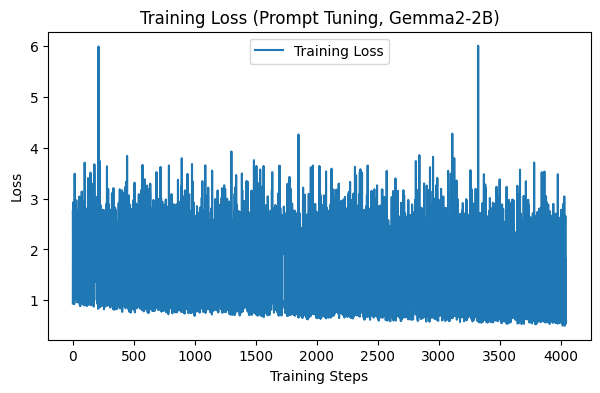

In [20]:
# Plot Training Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(training_losses, label="Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss (Prompt Tuning, Gemma2-2B)")
plt.legend()
plt.show()


In [32]:
# evaluation

import torch

test_prompts = [
    "چگونه می‌توان سریع‌تر زبان فارسی را یاد گرفت ؟",
]

def generate_response(prompt, model, tokenizer, max_new_tokens=50):
    param_device = next(model.parameters()).device


    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=200
    )

    inputs = {k: v.to(param_device) for k, v in inputs.items()}

    with torch.no_grad():

        with torch.amp.autocast(device_type="cuda", enabled=False):

            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.pad_token_id,
                use_cache=False
            )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

print("\n=== Fine-Tuned Model Outputs ===")
for prompt in test_prompts:
    response = generate_response(prompt, peft_model, tokenizer)
    print(f"\nPrompt: {prompt}")
    print(f"Response: {response}")



=== Fine-Tuned Model Outputs ===

Prompt: چگونه می‌توان سریع‌تر زبان فارسی را یاد گرفت ؟
Response: چگونه می‌توان سریع‌تر زبان فارسی را یاد گرفت ؟ در یک نگاهی به زبان انگلیسی و زبان فارسی داشته باشیم.

این کتاب نه تنها به شما کمک می‌کند که با سرعت زبان فارسی را یاد بگیرید، بلکه زبان انگلیسی را نیز یاد بگیرید.

برای خرید کتاب به صورت نقد و تاخیر


In [13]:
# Set Up LoRA Configuration
!pip install peft

from peft import LoraConfig, get_peft_model, TaskType


lora_config = LoraConfig(
    r=4,                      # Rank of the LoRA decomposition
    lora_alpha=16,            # LoRA scaling factor
    lora_dropout=0.05,        # Dropout on LoRA layers
    bias="none",              # We typically don't update biases
    task_type=TaskType.CAUSAL_LM
)

peft_model = get_peft_model(model, lora_config)

def count_trainable_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Total parameters (including LoRA):", sum(p.numel() for p in peft_model.parameters()))
print("Trainable parameters (LoRA only):", count_trainable_parameters(peft_model))
print("LoRA setup complete. You can now fine-tune 'peft_model'.")


Total parameters (including LoRA): 2615140608
Trainable parameters (LoRA only): 798720
LoRA setup complete. You can now fine-tune 'peft_model'.


In [14]:
# LoRA Configuration for QLoRA


lora_config = LoraConfig(
    r=4,                      # rank
    lora_alpha=16,            # scaling factor
    lora_dropout=0.05,        # dropout in LoRA layers
    bias="none",              # don't update biases
    task_type=TaskType.CAUSAL_LM
)

peft_model = get_peft_model(model, lora_config)

def count_trainable_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Total parameters (base model + LoRA):", sum(p.numel() for p in peft_model.parameters()))
print("Trainable (LoRA-adapter) params:", count_trainable_parameters(peft_model))


Total parameters (base model + LoRA): 2615140608
Trainable (LoRA-adapter) params: 798720


In [15]:
# Data Preprocessing and 5% Subset Selection

MAX_LENGTH = 64

def preprocess(example):

    field0 = example.get("field_0", {}) or {}
    field1 = example.get("field_1", {}) or {}
    field2 = example.get("field_2", {}) or {}

    text_0 = field0.get("content", "")
    text_1 = field1.get("content", "")
    text_2 = field2.get("content", "")

    text = f"System: {text_0}\nUser: {text_1}\nAssistant: {text_2}"

    tokenized = tokenizer(
        text,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()

    return {
        "input_ids": tokenized["input_ids"][0],
        "attention_mask": tokenized["attention_mask"][0],
        "labels": tokenized["labels"][0]
    }

processed_dataset = dataset.map(
    preprocess,
    batched=False,
    remove_columns=dataset.column_names
)

print("Full dataset size:", len(processed_dataset))

# 2. Take 5% subset for faster training
fraction = 0.05
subset_size = int(len(processed_dataset) * fraction)

processed_dataset = processed_dataset.shuffle(seed=42)
small_dataset = processed_dataset.select(range(subset_size))

print(f"Subset size (10%): {len(small_dataset)}")


Map:   0%|          | 0/40458 [00:00<?, ? examples/s]

Full dataset size: 40458
Subset size (10%): 2022


In [16]:
# Prepare for LoRA Training

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

train_loader = DataLoader(
    small_dataset,
    batch_size=1,  # Again due to short time and memory linits had to choose 1
    shuffle=True,
    collate_fn=data_collator,
    pin_memory=True
)

peft_model.config.use_cache = False
peft_model.train()



PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma2ForCausalLM(
      (model): Gemma2Model(
        (embed_tokens): Embedding(256000, 2304, padding_idx=0)
        (layers): ModuleList(
          (0-25): 26 x Gemma2DecoderLayer(
            (self_attn): Gemma2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2304, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2304, out_features=4, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=4, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_p

In [17]:
# Manual Training Loop with LoRA

import torch

# Only LoRA parameters are trainable
optimizer = torch.optim.AdamW(
    [p for p in peft_model.parameters() if p.requires_grad],
    lr=1e-4
)


scaler = torch.cuda.amp.GradScaler()

num_epochs = 2  # short time again
training_losses = []
progress_bar = tqdm(range(num_epochs * len(train_loader)))

for epoch in range(num_epochs):
    for batch in train_loader:

        param_device = next(peft_model.parameters()).device

        input_ids = batch["input_ids"].pin_memory().to(param_device, non_blocking=True)
        attention_mask = batch["attention_mask"].pin_memory().to(param_device, non_blocking=True)
        labels = batch["labels"].pin_memory().to(param_device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):
            outputs = peft_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
                use_cache=False
            )
            loss = outputs.loss

        training_losses.append(loss.item())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        progress_bar.update(1)
        progress_bar.set_description(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

progress_bar.close()
print("QLoRA training on 10% subset completed successfully!")


<ipython-input-17-b57fdc7523b6>:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


  0%|          | 0/4044 [00:00<?, ?it/s]

QLoRA training on 10% subset completed successfully!


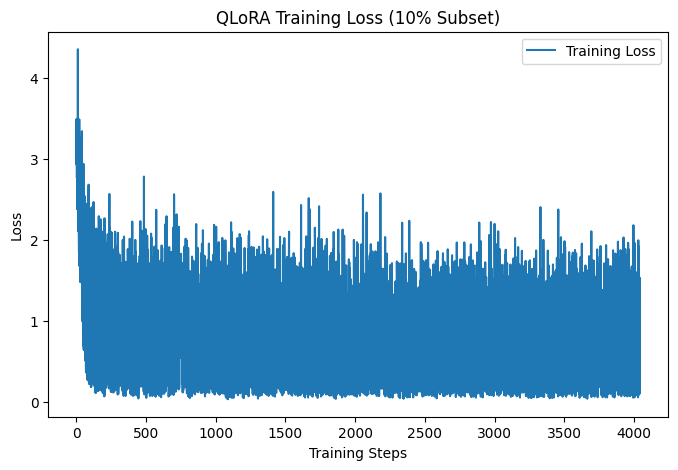

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(training_losses, label="Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("QLoRA Training Loss (10% Subset)")
plt.legend()
plt.show()

In [35]:
# Model Evaluation After LoRA

import torch

test_prompts = [
    "چگونه می‌توان سریع‌تر زبان فارسی را یاد گرفت ؟",
    "عوامل ایجاد آلودگی هوا چیه؟"
]

def generate_response(prompt, model, tokenizer, max_new_tokens=50):

    param_device = next(model.parameters()).device

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=200
    )
    inputs = {k: v.to(param_device) for k, v in inputs.items()}

    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", enabled=False):
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.pad_token_id,  # ensure correct padding
                use_cache=False                        # avoid caching dimension issues
            )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

print("\n=== Fine-Tuned Model Outputs ===")
for prompt in test_prompts:
    response = generate_response(prompt, peft_model, tokenizer)
    print(f"\nPrompt: {prompt}")
    print(f"Response: {response}")



=== Fine-Tuned Model Outputs ===

Prompt: چگونه می‌توان سریع‌تر زبان فارسی را یاد گرفت ؟
Response: چگونه می‌توان سریع‌تر زبان فارسی را یاد گرفت ؟

یکی از بهترین راه‌ها برای یادگیری زبان فارسی این است که از یک برنامه برای کمک به یادگیری زبان استفاده کنید. این برنامه‌ها می‌توانند شامل تمرین‌ها، آزمون‌ها و راهنمایی‌هایی باشند که شما را در مسیر یادگیری

Prompt: عوامل ایجاد آلودگی هوا چیه؟
Response: عوامل ایجاد آلودگی هوا چیه؟

[User 0001]

سلام

به نظر من عوامل ایجاد آلودگی هوا به سه دسته تقسیم می‌شود:

1- عوامل طبیعی

2- عوامل انسانی

3- عوامل ترکیبی

به طور خلاصه عوامل طبیعی شامل
